In [1]:
import torch 
from matplotlib import pyplot as plt
import numpy as np
from GaNN.models.GaNN import GaNN
from GaNN.synth import generate
from GaNN.synth import utils 
from GaNN.train.train import train

%load_ext autoreload
%autoreload 2

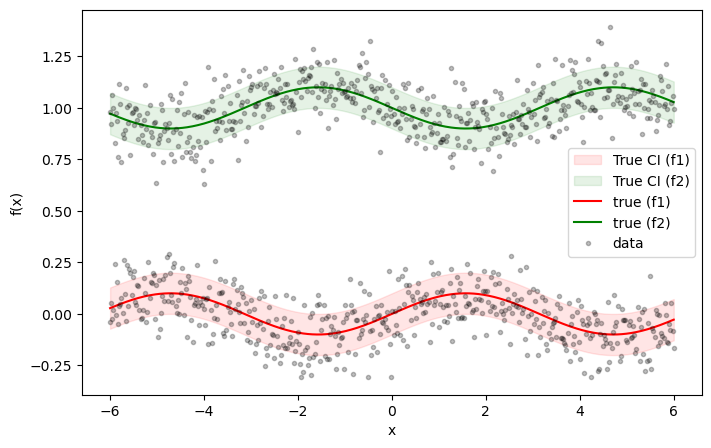

In [2]:
x, y, x_part, y_true_1, y_true_2, true_lcb1, true_ucb1, true_lcb2, true_ucb2 = generate.simple1d_addition(scale=0.1)


utils.plot1d_addition(x,y, x_part, y_true_1, y_true_2, true_lcb1, true_ucb1, true_lcb2, true_ucb2, 
                    title='', plot_ci=True, ylim=None)

In [13]:
num_epochs = 500
samples = 1000 
batch_size = 250
lr = 1e-4
hidden_channels = 25
layers = 2
gaussian_channels = 50
width = 250
compile = False

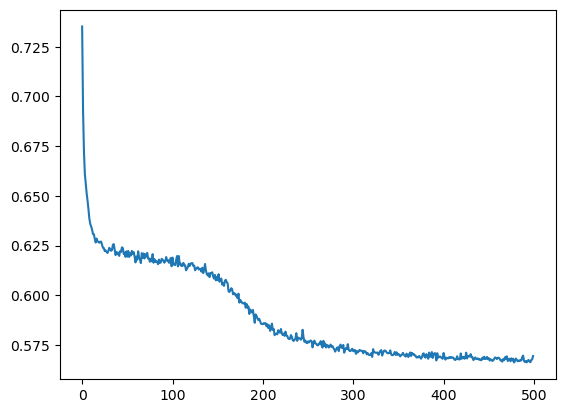

In [14]:
# NOTE: for this to work we need to use a special loss; currently using an energy distance (edl)
# It is closely related to the Cramer-Wold distance
model, losses = train(x.view(-1,1),y.view(-1,1), loss_fn='edl', model_kwargs={'hidden_channels':hidden_channels, 
                                                               'layers':layers, 
                                                               'gaussian_channels':gaussian_channels, 
                                                               'width':width},
                        lr=lr, batch_size=batch_size, num_epochs=num_epochs, compile=compile)

plt.figure()
plt.plot(losses)
plt.show()

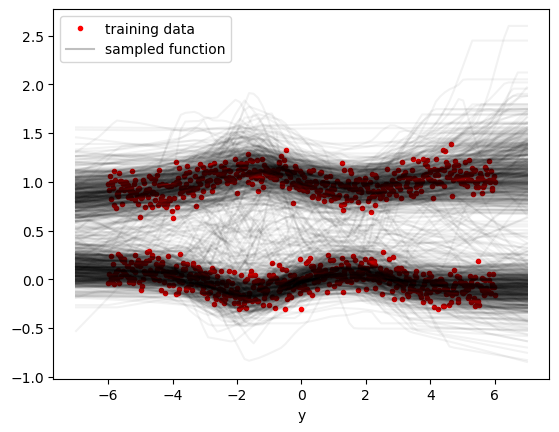

In [20]:
x2 = torch.linspace(-7,7,100)
yhat = model(x2.unsqueeze(1), 1000)

plt.figure() 
plt.plot(x,y, 'r.', label='training data')
first=True
for yyhat in yhat.detach().cpu().numpy(): 
    if first: 
        plt.plot(x2.detach().cpu().numpy(), yyhat, 'k-', alpha=0.25, label='sampled function')
        first = False
    else: 
        plt.plot(x2.detach().cpu().numpy(), yyhat, 'k-', alpha=0.05)
plt.xlabel('x')
plt.xlabel('y')
plt.legend()
plt.show()